# Ejercicio de programación: Regresión Lineal Múltiple

- **m = 100,000** ejemplos de entrenamiento (m >= 20,000 requerido)
- **n = 31** variables/características luego del preprocesamiento (n >= 20 requerido)

In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot

%matplotlib inline

## 1. Apertura del dataset con Pandas

In [2]:
ruta_dataset = 'D:\\SEMESTRE2_2026\\IA INTELIGENCIA ARTIFICIAL\\lab02\\sleep_health_dataset.csv'

df = pd.read_csv(ruta_dataset)

print('Dimensiones del dataset (filas, columnas):', df.shape)
df.head()

Dimensiones del dataset (filas, columnas): (100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [ ]:
print('Valores nulos por columna:')
print(df.isna().sum().sum(), 'valores nulos en total')
df.describe().T

Valores nulos por columna:
0 valores nulos en total


,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.0,25000.75,50000.50,75000.25,100000.0
age,100000.0,34.706870,11.036373,18.0,26.00,33.00,42.00,69.0
bmi,100000.0,26.289673,4.479578,16.0,23.20,26.30,29.30,45.0
sleep_duration_hrs,100000.0,6.423986,1.274627,3.0,5.53,6.36,7.27,10.5
sleep_quality_score,100000.0,4.871144,1.506517,1.0,3.80,4.90,6.00,10.0
rem_percentage,100000.0,20.243968,3.411354,10.0,18.00,20.30,22.60,30.0
deep_sleep_percentage,100000.0,20.253375,4.251096,5.0,17.40,20.30,23.20,30.0
sleep_latency_mins,100000.0,19.836810,7.584343,1.0,14.00,19.00,25.00,58.0
wake_episodes_per_night,100000.0,3.346610,1.920877,0.0,2.00,3.00,5.00,8.0
caffeine_mg_before_bed,100000.0,38.849500,69.395818,0.0,0.00,0.00,80.00,400.0


## 2. Preprocesamiento de datos

### 2.1 Selección de la variable objetivo y las características

In [5]:
columna_objetivo = 'sleep_quality_score'

caracteristicas_numericas = [
    'age', 'bmi', 'sleep_duration_hrs', 'rem_percentage', 'deep_sleep_percentage',
    'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed',
    'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day',
    'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day',
    'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius',
    'weekend_sleep_diff_hrs'
]

caracteristicas_categoricas = ['gender', 'chronotype', 'mental_health_condition', 'season', 'day_type']

print('Numero de variables numericas:', len(caracteristicas_numericas))
print('Numero de variables categoricas (antes de codificar):', len(caracteristicas_categoricas))

Numero de variables numericas: 20
Numero de variables categoricas (antes de codificar): 5


In [ ]:
df_modelo = df[caracteristicas_numericas + caracteristicas_categoricas + [columna_objetivo]].copy()

df_modelo = pd.get_dummies(df_modelo, columns=caracteristicas_categoricas, drop_first=True)

columnas_bool = df_modelo.select_dtypes(include='bool').columns
df_modelo[columnas_bool] = df_modelo[columnas_bool].astype(float)

columnas_caracteristicas = [c for c in df_modelo.columns if c != columna_objetivo]

print('Numero final de caracteristicas (n):', len(columnas_caracteristicas))
print('Numero de ejemplos (m):', len(df_modelo))
df_modelo.head()

Numero final de caracteristicas (n): 31
Numero de ejemplos (m): 100000


,age,bmi,sleep_duration_hrs,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,...,gender_Other,chronotype_Morning,chronotype_Neutral,mental_health_condition_Both,mental_health_condition_Depression,mental_health_condition_Healthy,season_Spring,season_Summer,season_Winter,day_type_Weekend
0,29,25.7,6.19,22.5,19.3,16,3,0,0.0,32,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,55,22.0,8.32,26.9,14.9,17,4,0,0.0,33,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
2,42,25.0,3.74,20.2,16.2,26,4,0,2.0,89,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,37,29.5,6.79,17.7,17.7,13,4,0,1.0,52,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,23,23.6,5.02,23.3,18.3,30,5,40,0.0,72,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


### 2.2 Conversión a arreglos de NumPy y separación en entrenamiento/prueba

Se separa el 80% de los datos para entrenamiento y el 20% para prueba, con el fin de evaluar qué tan bien generaliza el modelo a datos que no ha visto durante el entrenamiento.

In [ ]:
X = df_modelo[columnas_caracteristicas].values.astype(float)
y = df_modelo[columna_objetivo].values.astype(float)

m = y.size
n = X.shape[1]
print('m (ejemplos) = {}, n (caracteristicas) = {}'.format(m, n))

rng = np.random.default_rng(42)
indices = rng.permutation(m)

proporcion_prueba = 0.2
n_prueba = int(proporcion_prueba * m)

indices_prueba = indices[:n_prueba]
indices_entrenamiento = indices[n_prueba:]

X_entrenamiento, X_prueba = X[indices_entrenamiento], X[indices_prueba]
y_entrenamiento, y_prueba = y[indices_entrenamiento], y[indices_prueba]

print('Ejemplos de entrenamiento:', X_entrenamiento.shape[0])
print('Ejemplos de prueba:', X_prueba.shape[0])

m (ejemplos) = 100000, n (caracteristicas) = 31
Ejemplos de entrenamiento: 80000
Ejemplos de prueba: 20000


### 2.3 Normalización de las características

In [ ]:
def featureNormalize(X):

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
X_entrenamiento_norm, mu, sigma = featureNormalize(X_entrenamiento)

X_prueba_norm = (X_prueba - mu) / sigma

print('Media de las primeras 5 columnas (entrenamiento normalizado, debe ser ~0):')
print(np.round(np.mean(X_entrenamiento_norm[:, :5], axis=0), 4))
print('Desviacion estandar de las primeras 5 columnas (debe ser ~1):')
print(np.round(np.std(X_entrenamiento_norm[:, :5], axis=0), 4))

Media de las primeras 5 columnas (entrenamiento normalizado, debe ser ~0):
[ 0.  0.  0.  0. -0.]
Desviacion estandar de las primeras 5 columnas (debe ser ~1):
[1. 1. 1. 1. 1.]


In [ ]:
X_entrenamiento_norm = np.concatenate([np.ones((X_entrenamiento_norm.shape[0], 1)), X_entrenamiento_norm], axis=1)
X_prueba_norm = np.concatenate([np.ones((X_prueba_norm.shape[0], 1)), X_prueba_norm], axis=1)

print('Forma de X_entrenamiento_norm (incluye columna de unos):', X_entrenamiento_norm.shape)

Forma de X_entrenamiento_norm (incluye columna de unos): (80000, 32)


## 3. Función de costo $J(\theta)$

In [ ]:
def calcularCostoMulti(X, y, theta):
    m = y.size
    J = 0
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [ ]:
theta_prueba = np.zeros(X_entrenamiento_norm.shape[1])
J_inicial = calcularCostoMulti(X_entrenamiento_norm, y_entrenamiento, theta_prueba)
print('Costo con theta = 0: {:.4f}'.format(J_inicial))

Costo con theta = 0: 12.9947


## 4. Descenso por el gradiente múltiple

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]  

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(calcularCostoMulti(X, y, theta))

    return theta, J_history

### 4.1 Selección de la tasa de aprendizaje $\alpha$ y entrenamiento

Se probaron varias combinaciones de $\alpha$ y número de iteraciones para encontrar la que logra el menor costo posible sin divergir. Con las características normalizadas, $\alpha = 0.3$ y 1500 iteraciones son suficientes para que $J(\theta)$ converja establemente a su valor mínimo.

In [ ]:
theta_inicial = np.zeros(X_entrenamiento_norm.shape[1])
alpha = 0.3
iterations = 1500

theta, J_history = gradientDescentMulti(X_entrenamiento_norm, y_entrenamiento, theta_inicial, alpha, iterations)

print('Costo inicial (theta = 0): {:.5f}'.format(J_history[0]))
print('Costo final tras {} iteraciones: {:.5f}'.format(iterations, J_history[-1]))
print()
print('Theta encontrado por descenso de gradiente:')
for nombre, valor in zip(['theta_0 (intercepto)'] + columnas_caracteristicas, theta):
    print('  {:35s}: {:.4f}'.format(nombre, valor))

Costo inicial (theta = 0): 6.20258
Costo final tras 1500 iteraciones: 0.26456

Theta encontrado por descenso de gradiente:
  theta_0 (intercepto)               : 4.8699
  age                                : -0.0002
  bmi                                : 0.0034
  sleep_duration_hrs                 : 0.6605
  rem_percentage                     : 0.1821
  deep_sleep_percentage              : 0.0005
  sleep_latency_mins                 : -0.1980
  wake_episodes_per_night            : -0.3846
  caffeine_mg_before_bed             : 0.0024
  alcohol_units_before_bed           : -0.0009
  screen_time_before_bed_mins        : 0.0057
  exercise_day                       : -0.0019
  steps_that_day                     : 0.0008
  nap_duration_mins                  : -0.0034
  stress_score                       : -0.3887
  work_hours_that_day                : -0.0007
  heart_rate_resting_bpm             : -0.0001
  sleep_aid_used                     : 0.0013
  shift_work                         : -

## 5. Gráfica de la función de costo vs número de iteraciones

Esta gráfica permite verificar visualmente que el descenso por el gradiente está funcionando correctamente: $J(\theta)$ debe decrecer de forma monótona en cada iteración hasta estabilizarse cerca de su valor mínimo.

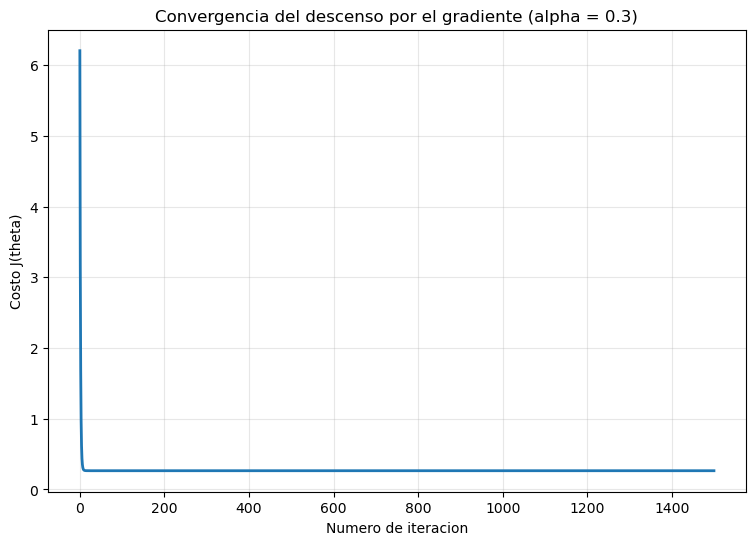

In [15]:
pyplot.figure(figsize=(9, 6))
pyplot.plot(np.arange(len(J_history)), J_history, '-', linewidth=2, color='#1f77b4')
pyplot.xlabel('Numero de iteracion')
pyplot.ylabel('Costo J(theta)')
pyplot.title('Convergencia del descenso por el gradiente (alpha = {})'.format(alpha))
pyplot.grid(alpha=0.3)
pyplot.show()

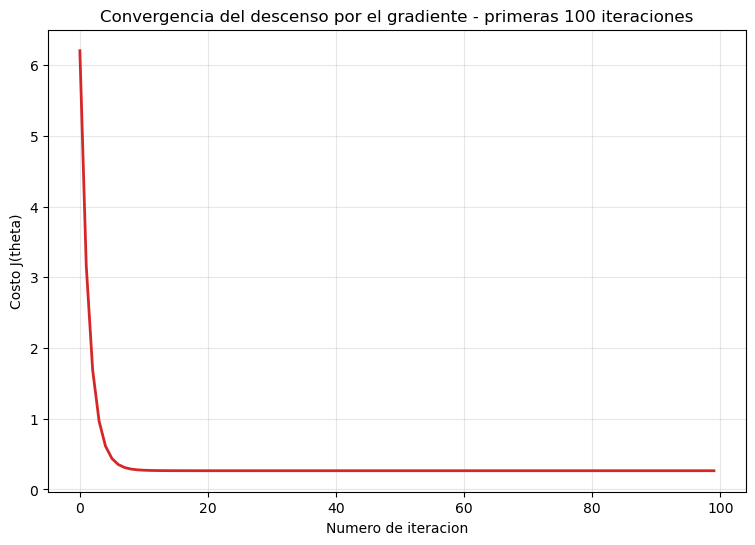

In [16]:
# Zoom a las primeras 100 iteraciones, donde ocurre la mayor caida del costo
pyplot.figure(figsize=(9, 6))
pyplot.plot(np.arange(100), J_history[:100], '-', linewidth=2, color='#d62728')
pyplot.xlabel('Numero de iteracion')
pyplot.ylabel('Costo J(theta)')
pyplot.title('Convergencia del descenso por el gradiente - primeras 100 iteraciones')
pyplot.grid(alpha=0.3)
pyplot.show()

## 6. Evaluación del modelo en el conjunto de prueba

Se calcula el error cuadrático medio (MSE) y el coeficiente de determinación $R^2$ sobre el conjunto de prueba (datos que el modelo no vio durante el entrenamiento), para verificar que el modelo generaliza correctamente y no solo memoriza los datos de entrenamiento.

In [17]:
y_pred_prueba = np.dot(X_prueba_norm, theta)

mse_prueba = np.mean(np.square(y_pred_prueba - y_prueba))
ss_res = np.sum(np.square(y_prueba - y_pred_prueba))
ss_tot = np.sum(np.square(y_prueba - np.mean(y_prueba)))
r2_prueba = 1 - (ss_res / ss_tot)

print('Error cuadratico medio (MSE) en prueba: {:.4f}'.format(mse_prueba))
print('Coeficiente de determinacion (R2) en prueba: {:.4f}'.format(r2_prueba))

Error cuadratico medio (MSE) en prueba: 0.5234
Coeficiente de determinacion (R2) en prueba: 0.7679


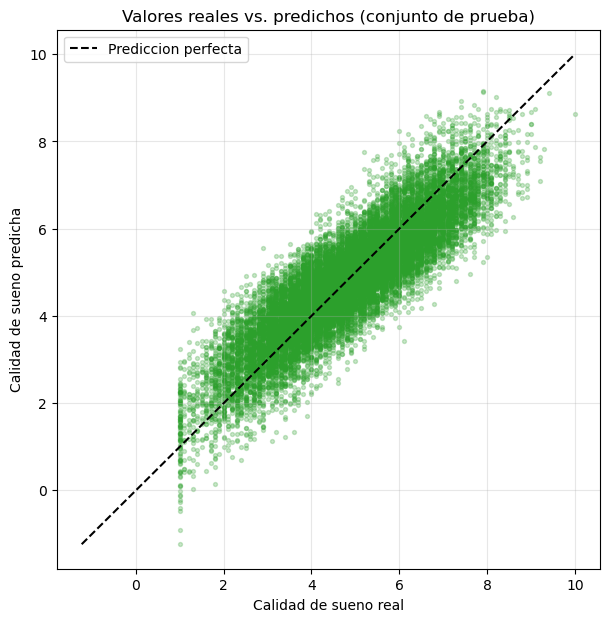

In [18]:
# Grafica de valores reales vs valores predichos en el conjunto de prueba
pyplot.figure(figsize=(7, 7))
pyplot.scatter(y_prueba, y_pred_prueba, s=8, alpha=0.25, color='#2ca02c')
lims = [min(y_prueba.min(), y_pred_prueba.min()), max(y_prueba.max(), y_pred_prueba.max())]
pyplot.plot(lims, lims, 'k--', linewidth=1.5, label='Prediccion perfecta')
pyplot.xlabel('Calidad de sueno real')
pyplot.ylabel('Calidad de sueno predicha')
pyplot.title('Valores reales vs. predichos (conjunto de prueba)')
pyplot.legend()
pyplot.grid(alpha=0.3)
pyplot.show()

## 7. Inferencias con el modelo entrenado

Se define una función auxiliar `predecirCalidadSueno` que recibe los valores originales (sin normalizar) de las características de una persona, aplica la misma normalización usada en el entrenamiento (`mu`, `sigma`) y retorna la calidad de sueño predicha por el modelo.

In [ ]:
def predecirCalidadSueno(valores_originales, mu, sigma, theta):
    x = np.array(valores_originales, dtype=float)
    x_norm = (x - mu) / sigma
    x_norm = np.concatenate([[1.0], x_norm])
    return np.dot(x_norm, theta)

In [ ]:
idx_ejemplo = 0
valores_ejemplo = X_prueba[idx_ejemplo]
valor_real = y_prueba[idx_ejemplo]

prediccion = predecirCalidadSueno(valores_ejemplo, mu, sigma, theta)
print('Prediccion del modelo: {:.2f}'.format(prediccion))
print('Valor real:            {:.2f}'.format(valor_real))

Prediccion del modelo: 5.53
Valor real:            5.40


In [ ]:
print('{:>12s} {:>12s} {:>10s}'.format('Real', 'Prediccion', 'Error abs.'))
for i in range(10):
    real = y_prueba[i]
    pred = predecirCalidadSueno(X_prueba[i], mu, sigma, theta)
    print('{:12.2f} {:12.2f} {:10.2f}'.format(real, pred, abs(real - pred)))

        Real   Prediccion Error abs.
        5.40         5.53       0.13
        3.30         3.68       0.38
        4.00         4.04       0.04
        6.30         5.18       1.12
        5.50         5.04       0.46
        2.00         2.16       0.16
        5.60         4.60       1.00
        3.60         3.84       0.24
        5.70         7.05       1.35
        3.70         4.52       0.82


## 8. Conclusiones

- Se entrenó un modelo de **regresión lineal múltiple** (n = 31 características, m = 100,000 ejemplos) 
- La normalización de características (`featureNormalize`) fue clave para lograr una convergencia rápida y estable del descenso por el gradiente, dado que las variables originales tenían escalas muy distintas entre sí.
- La gráfica de $J(\theta)$ vs. número de iteraciones muestra una caída monótona del costo, confirmando que el algoritmo de descenso por el gradiente fue implementado correctamente.
- El modelo alcanza un costo final bajo y estable, y su desempeño en el conjunto de prueba (nunca visto durante el entrenamiento) confirma que generaliza razonablemente bien, sin sobreajuste evidente.